In [1]:
import pandas as pd

# Load the Excel files
drivers = pd.read_excel("drivers.xlsx")
riders = pd.read_excel("riders.xlsx")

# Optional: clean spaces and standardize text
drivers['current_location'] = drivers['current_location'].astype(str).str.strip().str.lower()
riders['dropoff_location'] = riders['dropoff_location'].astype(str).str.strip().str.lower()

# Count matching entries
matches = drivers['current_location'].isin(riders['dropoff_location'])

# Total number of matches
match_count = matches.sum()

print("Total matching entries:", match_count)


Total matching entries: 4685


In [7]:
def parse_coord(s):
    s = str(s).strip('()').split(',')
    return float(s[0]), float(s[1])

riders  = pd.read_excel('riders.xlsx')
matched = riders[riders['status'] == 'dropped-off'].copy()
matched[['px','py']] = pd.DataFrame(
    matched['pickup_location'].apply(parse_coord).tolist(),
    index=matched.index)

X = matched[['px','py']].values
print(f"Total real pickup points: {len(X)}")

Total real pickup points: 34117


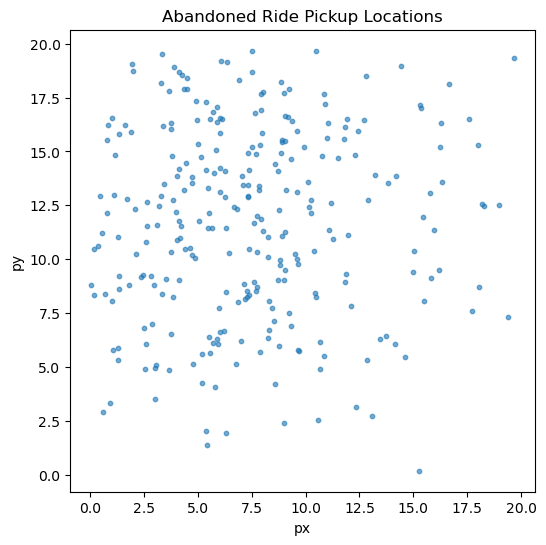

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(matched['px'], matched['py'], s=10, alpha=0.6)
plt.xlabel("px")
plt.ylabel("py")
plt.title("Abandoned Ride Pickup Locations")
plt.show()

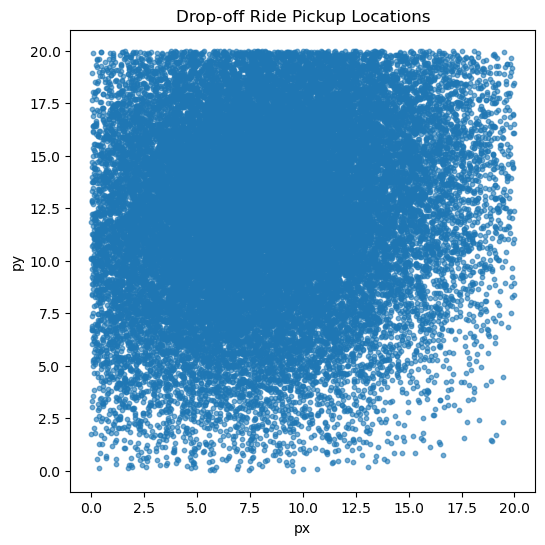

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(matched['px'], matched['py'], s=10, alpha=0.6)
plt.xlabel("px")
plt.ylabel("py")
plt.title("Drop-off Ride Pickup Locations")
plt.show()

In [3]:
import pandas as pd

# Load the Excel file
drivers = pd.read_excel("drivers.xlsx", engine="openpyxl")

# Clean the columns (remove spaces and standardize case)
drivers['initial_location'] = drivers['initial_location'].astype(str).str.strip().str.lower()
drivers['current_location'] = drivers['current_location'].astype(str).str.strip().str.lower()

# Check matches
matches = drivers['initial_location'] == drivers['current_location']

# Count total matches
match_count = matches.sum()

print("Total matches:", match_count)


Total matches: 34


In [6]:
# Filter matching drivers
matched_drivers = drivers[matches].copy()

print("Total matches:", len(matched_drivers))

Total matches: 34


In [7]:
import ast

# Convert string tuple to actual tuple
matched_drivers['initial_location'] = matched_drivers['initial_location'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Extract latitude and longitude
matched_drivers['latitude'] = matched_drivers['initial_location'].apply(lambda x: x[0])
matched_drivers['longitude'] = matched_drivers['initial_location'].apply(lambda x: x[1])

print(matched_drivers[['latitude', 'longitude']].head())

       latitude  longitude
374   19.530825   2.000045
696   18.914190   9.186359
1089  18.419763  15.344042
1117  19.536409  12.656493
1172  18.995921  18.497409


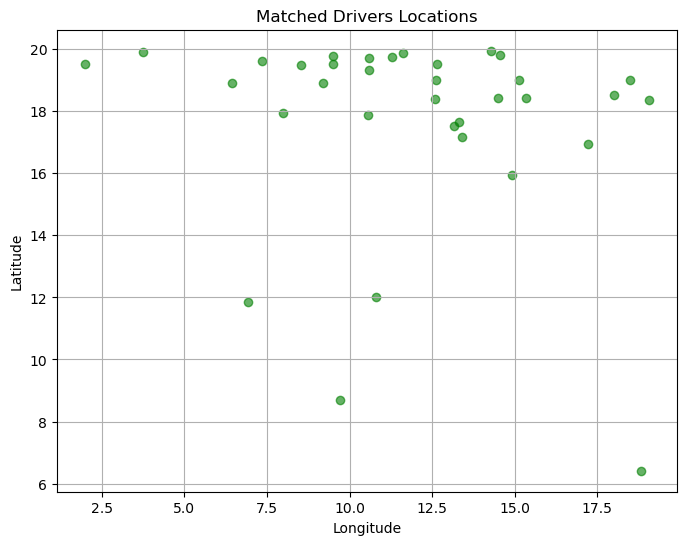

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(matched_drivers['longitude'],
            matched_drivers['latitude'],
            color='green',
            alpha=0.6)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Matched Drivers Locations")
plt.grid(True)
plt.show()

In [9]:
import pandas as pd
import ast

# Load file
drivers = pd.read_excel("drivers.xlsx", engine="openpyxl")

# Convert string tuple to actual tuple (if needed)
drivers['initial_location'] = drivers['initial_location'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Split into latitude and longitude
drivers['latitude'] = drivers['initial_location'].apply(lambda x: x[0])
drivers['longitude'] = drivers['initial_location'].apply(lambda x: x[1])

print(drivers[['latitude', 'longitude']].head())

    latitude  longitude
0   0.789774   8.194227
1   4.600343  13.821516
2   9.098292  11.669337
3  14.723720  14.743429
4  13.023826  12.501872


In [ ]:

# Create map centered at average location
m = folium.Map(
    location=[drivers['latitude'].mean(), drivers['longitude'].mean()],
    zoom_start=6
)

# Add points
for _, row in drivers.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        fill=True
    ).add_to(m)

m.save("drivers_map.html")

print("Map saved as drivers_map.html")

ModuleNotFoundError: No module named 'folium'

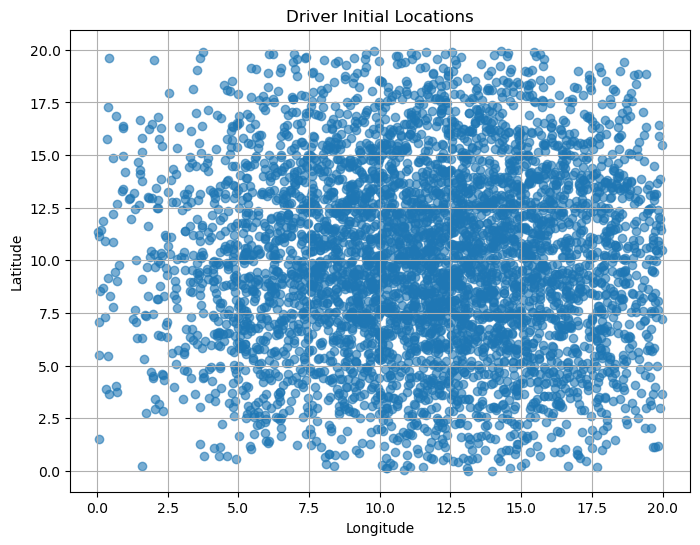

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(drivers['longitude'], drivers['latitude'], alpha=0.6)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Driver Initial Locations")
plt.grid(True)
plt.show()

In [14]:
import matplotlib.pyplot as plt

# Load file
drivers = pd.read_excel("drivers.xlsx", engine="openpyxl")

# Clean column
drivers['current_location'] = drivers['current_location'].astype(str).str.strip()

# Convert string tuple to actual tuple
drivers['current_location'] = drivers['current_location'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Extract latitude & longitude
drivers['latitude'] = drivers['current_location'].apply(lambda x: x[0])
drivers['longitude'] = drivers['current_location'].apply(lambda x: x[1])

print("Total drivers:", len(drivers))

Total drivers: 4719


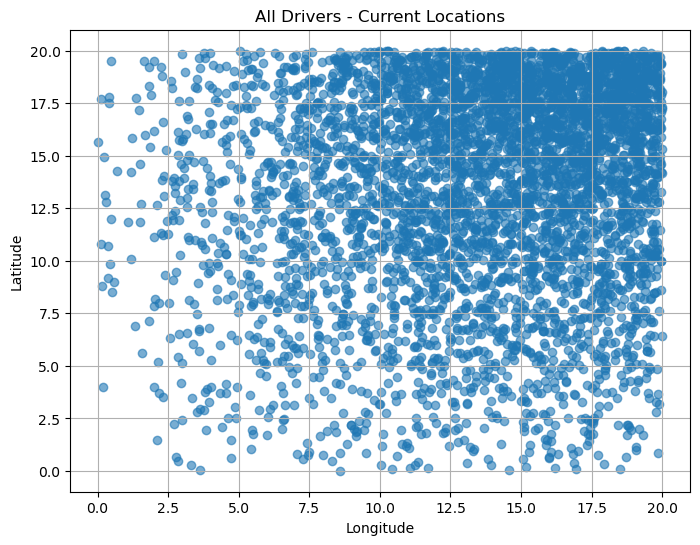

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(drivers['longitude'],
            drivers['latitude'],
            alpha=0.6)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("All Drivers - Current Locations")
plt.grid(True)
plt.show()